In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [43]:
generation_1 = pd.read_csv("Plant_1_Generation_Data.csv.")
weather_1 = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

generation_2 = pd.read_csv("Plant_2_Generation_Data.csv")
weather_2 = pd.read_csv("Plant_2_Weather_Sensor_Data.csv")

print("Plant 1 Generation:", generation_1.shape)
print("Plant 1 Weather:", weather_1.shape)
print("Plant 2 Generation:", generation_2.shape)
print("Plant 2 Weather:", weather_2.shape)

Plant 1 Generation: (68778, 7)
Plant 1 Weather: (3182, 6)
Plant 2 Generation: (67698, 7)
Plant 2 Weather: (3259, 6)


In [57]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [58]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "SVR": SVR(C=1.0, kernel="rbf"),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

print("Models created:", len(models))

Models created: 9


In [59]:
results = []

for name, model in models.items():

    # Use scaled data for models sensitive to feature scale
    if name in ["SVR", "KNN", "Ridge Regression", "Lasso Regression", "ElasticNet"]:
        Xtr = X_train_scaled
        Xte = X_test_scaled
    else:
        Xtr = X_train
        Xte = X_test

    model.fit(Xtr, y_train)

    predictions = model.predict(Xte)

    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)

    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

results_df

,Model,R2,RMSE,MAE
0,Random Forest,0.999991,1.156750,0.143945
1,Decision Tree,0.999991,1.190071,0.179896
2,Linear Regression,0.999986,1.461325,0.714509
3,Ridge Regression,0.999986,1.461417,0.717655
4,Lasso Regression,0.999986,1.461424,0.715381
5,ElasticNet,0.999986,1.480359,0.805702
6,Gradient Boosting,0.999964,2.363176,1.173769
7,KNN,0.997854,18.208686,9.648766
8,SVR,0.988867,41.478739,20.642540


In [60]:
from sklearn.pipeline import Pipeline

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_model.fit(X_train_scaled, y_train)

poly_predictions = poly_model.predict(X_test_scaled)

poly_r2 = r2_score(y_test, poly_predictions)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_predictions))
poly_mae = mean_absolute_error(y_test, poly_predictions)

print("Polynomial Regression")
print("R2   :", poly_r2)
print("RMSE :", poly_rmse)
print("MAE  :", poly_mae)

Polynomial Regression
R2   : 0.9999910602824267
RMSE : 1.1753737341050314
MAE  : 0.27116043335961865


In [61]:
results.append({
    "Model": "Polynomial Regression",
    "R2": poly_r2,
    "RMSE": poly_rmse,
    "MAE": poly_mae
})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R2", ascending=False).reset_index(drop=True)

results_df

,Model,R2,RMSE,MAE
0,Random Forest,0.999991,1.156750,0.143945
1,Polynomial Regression,0.999991,1.175374,0.271160
2,Decision Tree,0.999991,1.190071,0.179896
3,Linear Regression,0.999986,1.461325,0.714509
4,Ridge Regression,0.999986,1.461417,0.717655
5,Lasso Regression,0.999986,1.461424,0.715381
6,ElasticNet,0.999986,1.480359,0.805702
7,Gradient Boosting,0.999964,2.363176,1.173769
8,KNN,0.997854,18.208686,9.648766
9,SVR,0.988867,41.478739,20.642540


In [62]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


rf_cv_scores = cross_val_score(
    models["Random Forest"],
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Random Forest - 5 Fold CV R²")
print("Scores:", rf_cv_scores)
print("Mean CV R²:", rf_cv_scores.mean())



poly_cv_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_cv_scores = cross_val_score(
    poly_cv_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("\nPolynomial Regression - 5 Fold CV R²")
print("Scores:", poly_cv_scores)
print("Mean CV R²:", poly_cv_scores.mean())

Random Forest - 5 Fold CV R²
Scores: [0.99999887 0.9999992  0.99999915 0.99999945 0.99999895]
Mean CV R²: 0.9999991238626544

Polynomial Regression - 5 Fold CV R²
Scores: [0.99999858 0.99999893 0.99999891 0.99999923 0.99999873]
Mean CV R²: 0.9999988769143382


In [63]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [64]:
rf = RandomForestRegressor(random_state=42)

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV R²:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Best CV R²:
0.9999991329792779


In [35]:
best_rf = rf_grid.best_estimator_

rf_predictions = best_rf.predict(X_test)

rf_tuned_r2 = r2_score(y_test, rf_predictions)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_tuned_mae = mean_absolute_error(y_test, rf_predictions)

print("Tuned Random Forest")
print("R²   :", rf_tuned_r2)
print("RMSE :", rf_tuned_rmse)
print("MAE  :", rf_tuned_mae)

Tuned Random Forest
R²   : 0.9999913297660644
RMSE : 1.1575226284944051
MAE  : 0.14432872191026572


In [36]:


gb = GradientBoostingRegressor(random_state=42)

gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

print("\nBest CV R²:")
print(gb_grid.best_score_)

Best Gradient Boosting Parameters:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}

Best CV R²:
0.9999973545971773


In [37]:


best_gb = gb_grid.best_estimator_

gb_predictions = best_gb.predict(X_test)

gb_tuned_r2 = r2_score(y_test, gb_predictions)
gb_tuned_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
gb_tuned_mae = mean_absolute_error(y_test, gb_predictions)

print("Tuned Gradient Boosting")
print("R²   :", gb_tuned_r2)
print("RMSE :", gb_tuned_rmse)
print("MAE  :", gb_tuned_mae)

Tuned Gradient Boosting
R²   : 0.9999896756226735
RMSE : 1.2631240849878385
MAE  : 0.351614234209707


In [38]:
# Compare Before and After Hyperparameter Tuning

tuning_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Random Forest",
        "Gradient Boosting",
        "Gradient Boosting"
    ],
    "Version": [
        "Before Tuning",
        "After Tuning",
        "Before Tuning",
        "After Tuning"
    ],
    "R2": [
        results_df.loc[results_df["Model"] == "Random Forest", "R2"].iloc[0],
        rf_tuned_r2,
        results_df.loc[results_df["Model"] == "Gradient Boosting", "R2"].iloc[0],
        gb_tuned_r2
    ],
    "RMSE": [
        results_df.loc[results_df["Model"] == "Random Forest", "RMSE"].iloc[0],
        rf_tuned_rmse,
        results_df.loc[results_df["Model"] == "Gradient Boosting", "RMSE"].iloc[0],
        gb_tuned_rmse
    ],
    "MAE": [
        results_df.loc[results_df["Model"] == "Random Forest", "MAE"].iloc[0],
        rf_tuned_mae,
        results_df.loc[results_df["Model"] == "Gradient Boosting", "MAE"].iloc[0],
        gb_tuned_mae
    ]
})

tuning_results

,Model,Version,R2,RMSE,MAE
0,Random Forest,Before Tuning,0.999991,1.156750,0.143945
1,Random Forest,After Tuning,0.999991,1.157523,0.144329
2,Gradient Boosting,Before Tuning,0.999964,2.363176,1.173769
3,Gradient Boosting,After Tuning,0.999990,1.263124,0.351614


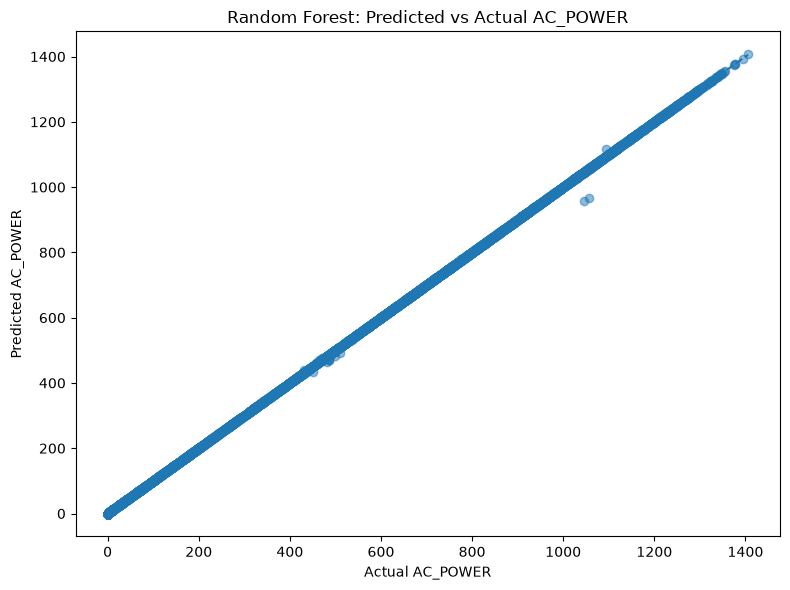

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_predictions, alpha=0.5)


plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual AC_POWER")
plt.ylabel("Predicted AC_POWER")
plt.title("Random Forest: Predicted vs Actual AC_POWER")

plt.tight_layout()
plt.show()

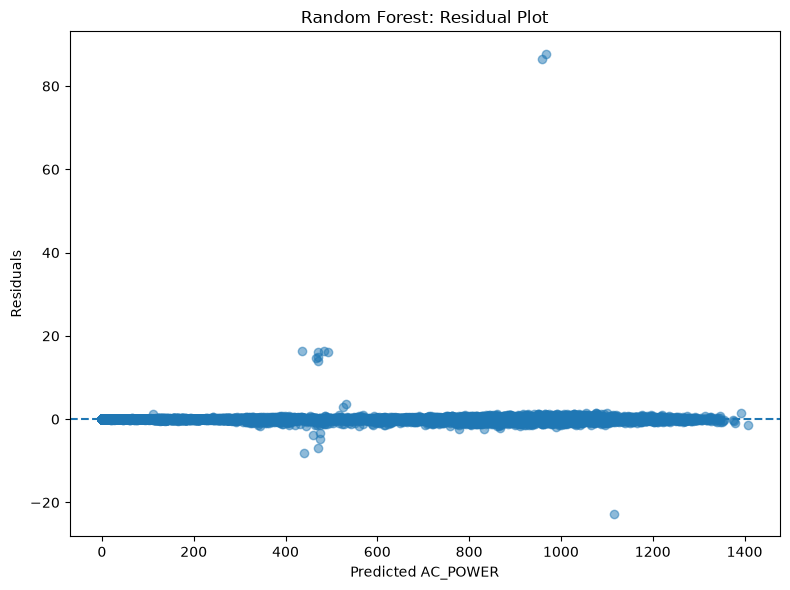

In [40]:

rf_residuals = y_test - rf_predictions

plt.figure(figsize=(8, 6))

plt.scatter(rf_predictions, rf_residuals, alpha=0.5)


plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted AC_POWER")
plt.ylabel("Residuals")
plt.title("Random Forest: Residual Plot")

plt.tight_layout()
plt.show()

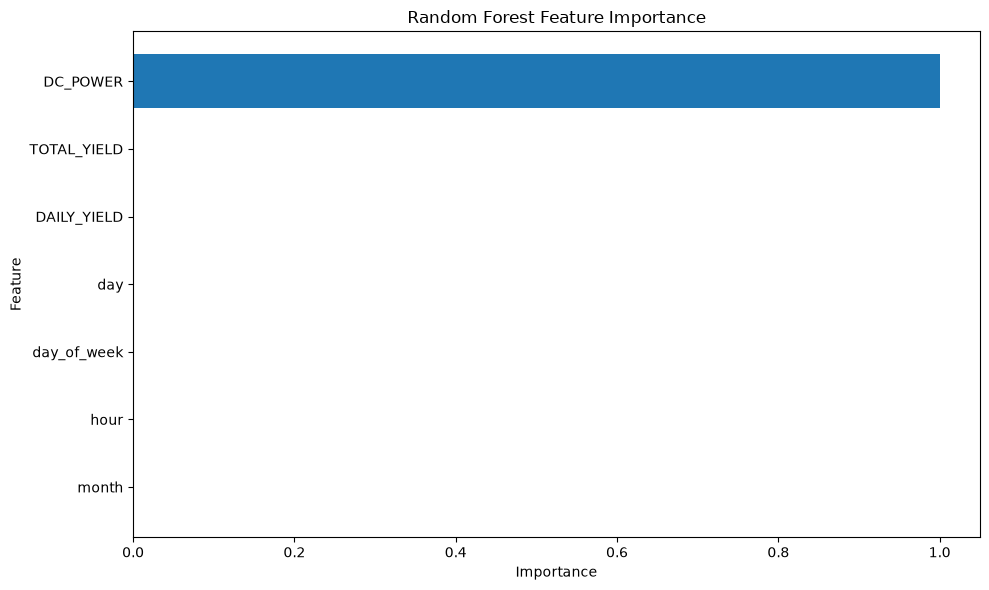

In [41]:


feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Regression Summary and Conclusion

- Ten regression algorithms were trained and evaluated using the same train-test split.
- Random Forest achieved excellent predictive performance with an R² of approximately 0.999991.
- Polynomial Regression also achieved very high predictive performance with an R² of approximately 0.999991.
- Five-fold cross-validation was performed for Random Forest and Polynomial Regression to assess model performance across multiple folds.
- Hyperparameter tuning was performed using GridSearchCV for Random Forest and Gradient Boosting.
- Gradient Boosting showed a significant improvement after hyperparameter tuning, particularly in RMSE and MAE.
- The Predicted vs Actual plot shows that the Random Forest predictions are very close to the actual AC_POWER values.
- The residual plot shows that most prediction errors are concentrated around zero.
- Feature importance analysis shows that DC_POWER is the most influential feature for predicting AC_POWER.